In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from ensemble_model import EnsembleModel
import joblib

## 1. Load the Dataset

The Dataset contains one row per completed match.

Each row contains:
- the final match outcome('team0_won')
- aggreagted statistics for both teams
- statistics for each of the six players on each team
- hero an lane assignment

Statistics measured at the 5-minute snapshot.

## 2. Feature Engineering

The engineered features fall into several groups:

### Team compositions and distributions
- Carry share
- Networth standart deviation
- Richest player relative to team avarage

### Team performance
- Team kill/death ratio (KDR)

### Team-to-team differences
- Networth difference
- Damage difference
- Avarage level difference
- Carry networth difference
- KDR difference
- Gold-per-minute difference
- Objective damage difference

### Relative ratios
- Networth ratio
- Damage ratio
- Objective damage ratio

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

new_features = pd.DataFrame({
    "team0_carry_share" : (df["team0_p1_networth"]/df["team0_team_total_networth"]),
    "team1_carry_share" : (df["team1_p1_networth"]/df["team1_team_total_networth"]),
    "team0_networth_std" : df[["team0_p1_networth","team0_p2_networth","team0_p3_networth","team0_p4_networth","team0_p5_networth","team0_p6_networth"]].std(axis=1),
    "team1_networth_std" : df[["team1_p1_networth","team1_p2_networth","team1_p3_networth","team1_p4_networth","team1_p5_networth","team1_p6_networth"]].std(axis=1),
    "team0_team_kdr" : (df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1)),
    "team1_team_kdr" : (df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "team0_richest_vs_team_avg" : (df["team0_p1_networth"]/(df["team0_team_total_networth"]/6)),
    "team1_richest_vs_team_avg" : (df["team1_p1_networth"]/(df["team1_team_total_networth"]/6)),
    'networth_diff': df['team0_team_total_networth'] - df['team1_team_total_networth'],
    "damage_diff":df["team0_team_total_damage"]-df["team1_team_total_damage"],
    "level_diff":df["team0_team_avg_level"]-df["team1_team_avg_level"],
    "carry_diff":df["team0_p1_networth"] - df["team1_p1_networth"],
    "kdr_diff":(df["team0_team_total_kills"]/(df["team0_team_total_deaths"]+1))-(df["team1_team_total_kills"]/(df["team1_team_total_deaths"]+1)),
    "gpm_diff" : (df["team0_team_gold_per_minute"]-df["team1_team_gold_per_minute"]),
    "objective_diff" : (df["team0_team_total_objectivedamage"]-df["team1_team_total_objectivedamage"]),
    "networth_ratio" : (df["team0_team_total_networth"]/(df["team1_team_total_networth"]+1)),
    "damage_ratio" : (df["team0_team_total_damage"]/(df["team1_team_total_damage"]+1)),
    "objective_ratio" : (df["team0_team_total_objectivedamage"]/(df["team1_team_total_objectivedamage"]+1))
})
df = pd.concat([df, new_features],axis=1)
print(df.shape)
df


(17702, 202)


,match_id,team0_won,team0_team_total_kills,team0_team_total_deaths,team0_team_total_networth,team0_team_total_damage,team0_team_total_objectivedamage,team0_team_avg_level,team0_team_gold_per_minute,team0_p1_hero,...,networth_diff,damage_diff,level_diff,carry_diff,kdr_diff,gpm_diff,objective_diff,networth_ratio,damage_ratio,objective_ratio
0,1741000,1,40,23,141415,92902,24814,20.166667,942.766629,2,...,5421,15008,0.500000,-1225,1.155039,36.139999,5088,1.039854,1.192657,1.257870
1,30579330,0,44,33,131636,98973,11407,24.833333,877.573298,1,...,-14039,-7584,-1.000000,-277,0.576726,-93.593330,-11581,0.903622,0.928818,0.496194
2,38972692,0,25,27,120000,64990,12389,19.833333,799.999968,12,...,-12244,-8462,-1.000000,-4888,-0.070106,-81.626663,-2530,0.907407,0.884783,0.830362
3,38763513,1,36,37,146246,102620,12265,21.833333,974.973294,14,...,-744,-1879,-0.333333,-3398,0.052632,-4.960000,299,0.994932,0.982010,1.024902
4,39506973,1,49,13,164230,103525,18923,23.666667,1094.866623,13,...,39823,39180,3.333333,9173,3.269231,265.486656,10103,1.320092,1.608880,2.145222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17697,83270891,1,48,44,167802,165695,32403,27.000000,1118.679955,13,...,1883,1454,0.166667,-1348,0.226667,12.553333,4567,1.011343,1.008847,1.164026
17698,83271419,0,23,37,134693,113590,9522,23.333333,897.953297,66,...,-6453,-11425,-0.833333,-2113,-0.817814,-43.019998,-16080,0.954275,0.908604,0.371910
17699,83270998,1,36,23,166414,123187,20358,26.833333,1109.426622,25,...,28594,6053,3.166667,4364,0.905405,190.626659,4415,1.207465,1.051667,1.276844
17700,83271597,1,48,18,182911,149166,58739,28.833333,1253.673698,4,...,67991,48011,7.500000,8404,2.173375,466.010947,47371,1.591624,1.474613,5.166593


## 3. Train/Test Split

The data is split into 80% training and 20% test data

In [ ]:
X = df.drop(columns=["team0_won","match_id"])

y = df["team0_won"]

categorical_columns = []
for team in [0,1]:
    for i in range(1,7):
        categorical_columns.append(f'team{team}_p{i}_hero')
        categorical_columns.append(f'team{team}_p{i}_lane')

X = pd.get_dummies(X, columns=categorical_columns)
feature_columns = joblib.load("YOUR_PATH_HERE")
X = X.reindex(columns=feature_columns, fill_value=0)
print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X.columns.to_list()

(17702, 679)


['team0_team_total_kills',
 'team0_team_total_deaths',
 'team0_team_total_networth',
 'team0_team_total_damage',
 'team0_team_total_objectivedamage',
 'team0_team_avg_level',
 'team0_team_gold_per_minute',
 'team0_p1_kills',
 'team0_p1_deaths',
 'team0_p1_assists',
 'team0_p1_networth',
 'team0_p1_damage',
 'team0_p1_creeps',
 'team0_p1_level',
 'team0_p1_objective_damage',
 'team0_p1_denies',
 'team0_p1_gold_per_minute',
 'team0_p1_player_healing',
 'team0_p1_self_healing',
 'team0_p2_kills',
 'team0_p2_deaths',
 'team0_p2_assists',
 'team0_p2_networth',
 'team0_p2_damage',
 'team0_p2_creeps',
 'team0_p2_level',
 'team0_p2_objective_damage',
 'team0_p2_denies',
 'team0_p2_gold_per_minute',
 'team0_p2_player_healing',
 'team0_p2_self_healing',
 'team0_p3_kills',
 'team0_p3_deaths',
 'team0_p3_assists',
 'team0_p3_networth',
 'team0_p3_damage',
 'team0_p3_creeps',
 'team0_p3_level',
 'team0_p3_objective_damage',
 'team0_p3_denies',
 'team0_p3_gold_per_minute',
 'team0_p3_player_healing'

## 4. Baseline Performance

As an initial benchmark, an XGB classifier and RandomForest classifier are trained with a relatively simple configurations.

The baseline models achive roughly 79% test accuracy

In [ ]:
model_xgb = XGBClassifier(n_estimators=300,max_depth=3,learning_rate=0.05,random_state=42)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy_xgb}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.791019486020898

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1761
           1       0.79      0.79      0.79      1780

    accuracy                           0.79      3541
   macro avg       0.79      0.79      0.79      3541
weighted avg       0.79      0.79      0.79      3541



In [5]:
importance = pd.DataFrame({"feature": X.columns, "importance": model_xgb.feature_importances_})

importance = importance.sort_values(by="importance",ascending=False)

importance

,feature,importance
173,networth_ratio,0.136936
166,networth_diff,0.082379
168,level_diff,0.035784
170,kdr_diff,0.026647
171,gpm_diff,0.021325
...,...,...
104,team1_p2_level,0.000000
641,team1_p6_hero_6,0.000000
101,team1_p2_networth,0.000000
666,team1_p6_hero_66,0.000000


In [ ]:
model_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy}")

print("\nRandom Forest Report:")

print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.7831121152216888

Random Forest Report:

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1761
           1       0.78      0.78      0.78      1780

    accuracy                           0.78      3541
   macro avg       0.78      0.78      0.78      3541
weighted avg       0.78      0.78      0.78      3541



In [7]:
rf_importance = pd.DataFrame({"feature": X.columns,"importance": model_rf.feature_importances_})

rf_importance = rf_importance.sort_values(by="importance",ascending=False)

print(rf_importance.head(20))

                              feature  importance
173                    networth_ratio    0.061783
166                     networth_diff    0.061031
168                        level_diff    0.048887
171                          gpm_diff    0.042221
162                    team0_team_kdr    0.027684
163                    team1_team_kdr    0.027444
172                    objective_diff    0.027352
175                   objective_ratio    0.027152
170                          kdr_diff    0.023725
169                        carry_diff    0.023142
6          team0_team_gold_per_minute    0.017183
2           team0_team_total_networth    0.016845
84               team1_team_avg_level    0.014065
85         team1_team_gold_per_minute    0.013949
4    team0_team_total_objectivedamage    0.013536
174                      damage_ratio    0.013317
81          team1_team_total_networth    0.011994
167                       damage_diff    0.011854
83   team1_team_total_objectivedamage    0.011431


## 5. Tuned XGBoost

The next experiment uses a more regularized XGBoost configuration.

In [ ]:
model_xgb = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.7,

    colsample_bytree=0.7,

    min_child_weight=7,

    gamma=2,

    reg_alpha=2,

    reg_lambda=10,

    random_state=42,
)
model_xgb.fit(X_train, y_train)
predictions = model_xgb.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for XGB: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy for XGB: 0.7896074555210393

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.78      0.79      1761
           1       0.79      0.80      0.79      1780

    accuracy                           0.79      3541
   macro avg       0.79      0.79      0.79      3541
weighted avg       0.79      0.79      0.79      3541



The tuned model achives ~79% test accuracy and ~83.3% train accuracy

In [ ]:
train_acc = model_xgb.score(X_train, y_train)

test_acc = model_xgb.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8331332533013205
0.7896074555210393


### 6. ROC-AUC

Because the final application outputs a win probability rather than only a binary prediction, accuracy alone is not sufficient.

ROC-AUC measures how well the model ranks winning teams above losing teams across different probability thresholds.

For the tuned XGBoost model, the test ROC-AUC is approximately 0.871.

In [ ]:
from sklearn.metrics import roc_auc_score

probs=model_xgb.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,probs))

0.8718973514793051


## 7. CatBoost

CatBoost is evaluated as a second gradient-boosting model.

It recieves approximately 78.7% test accuracy and 0.872 ROC-AUC score.

In [ ]:
model_cat = CatBoostClassifier(

    iterations=1500,

    depth=4,

    learning_rate=0.02,

    l2_leaf_reg=15,

    min_data_in_leaf=30,

    random_strength=5,

    bagging_temperature=2,

    verbose=100,

    random_seed=42
)

model_cat.fit(X_train, y_train)

probs = model_cat.predict_proba(X_test)[:,1]

predictions = model_cat.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy for CAT: {accuracy}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

pred=(probs>0.5)

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs))

0:	learn: 0.6840583	total: 146ms	remaining: 3m 38s
100:	learn: 0.4698128	total: 937ms	remaining: 13s
200:	learn: 0.4531981	total: 1.69s	remaining: 10.9s
300:	learn: 0.4473092	total: 2.45s	remaining: 9.74s
400:	learn: 0.4438118	total: 3.26s	remaining: 8.93s
500:	learn: 0.4400867	total: 4.06s	remaining: 8.09s
600:	learn: 0.4340630	total: 4.83s	remaining: 7.23s
700:	learn: 0.4260141	total: 5.63s	remaining: 6.42s
800:	learn: 0.4182988	total: 6.44s	remaining: 5.62s
900:	learn: 0.4113420	total: 7.22s	remaining: 4.8s
1000:	learn: 0.4049884	total: 7.97s	remaining: 3.97s
1100:	learn: 0.3988487	total: 8.74s	remaining: 3.17s
1200:	learn: 0.3928475	total: 9.51s	remaining: 2.37s
1300:	learn: 0.3874525	total: 10.2s	remaining: 1.56s
1400:	learn: 0.3819794	total: 11s	remaining: 774ms
1499:	learn: 0.3766377	total: 11.7s	remaining: 0us
Accuracy for CAT: 0.7881954250211805

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.78      0.79      1761

In [ ]:
train_acc = model_cat.score(X_train, y_train)

test_acc = model_cat.score(X_test, y_test)

print(train_acc)
print(test_acc)

0.8282607160511263
0.7881954250211805


## 8. Ensemble Model

The final predictor combines the XGBoost and CatBoost models using simple soft-voting ensemble. For each match, both models produce class probabilities, which are then avaraged using arithmetic mean.

On the test set ensemble achieves approxiamtely 78.8% accuracy and 0.872 ROC-AUC score.

In [ ]:
ensemble = EnsembleModel(model_xgb, model_cat)
joblib.dump(ensemble, 'YOUR_PATH_HERE')

pred = ensemble.predict(X_test)
probs = ensemble.predict_proba(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print(accuracy_score(y_test, pred))

print(roc_auc_score(y_test, probs[:, 1]))

0.7881954250211805
0.8726476912377417


## 9. Calibration Curve

A calibration curve compares predicted probabilities with the observed frequency of the positive class.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated = CalibratedClassifierCV(model_xgb, method='isotonic', cv=5)

calibrated.fit(X_train, y_train)

probs = calibrated.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.8715250527981421


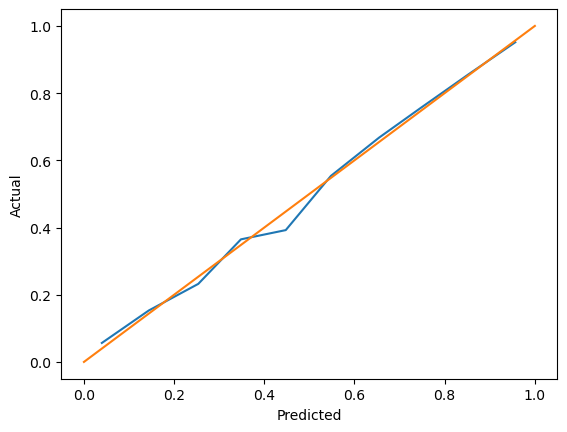

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test,probs, n_bins=10)

plt.plot(prob_pred, prob_true)

plt.plot([0,1], [0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## 10. Model Explainability with SHAP

SHAP is used to investigate which features influence the XGBoost predictions.

Two visualizations are produced:

1. A SHAP summary plot showing the overall importance and direction of feature contributions.
2. A bar plot showing aggregated feature importance.

This provides an interpretable view of which aspects of the game influance the model prediction the most.

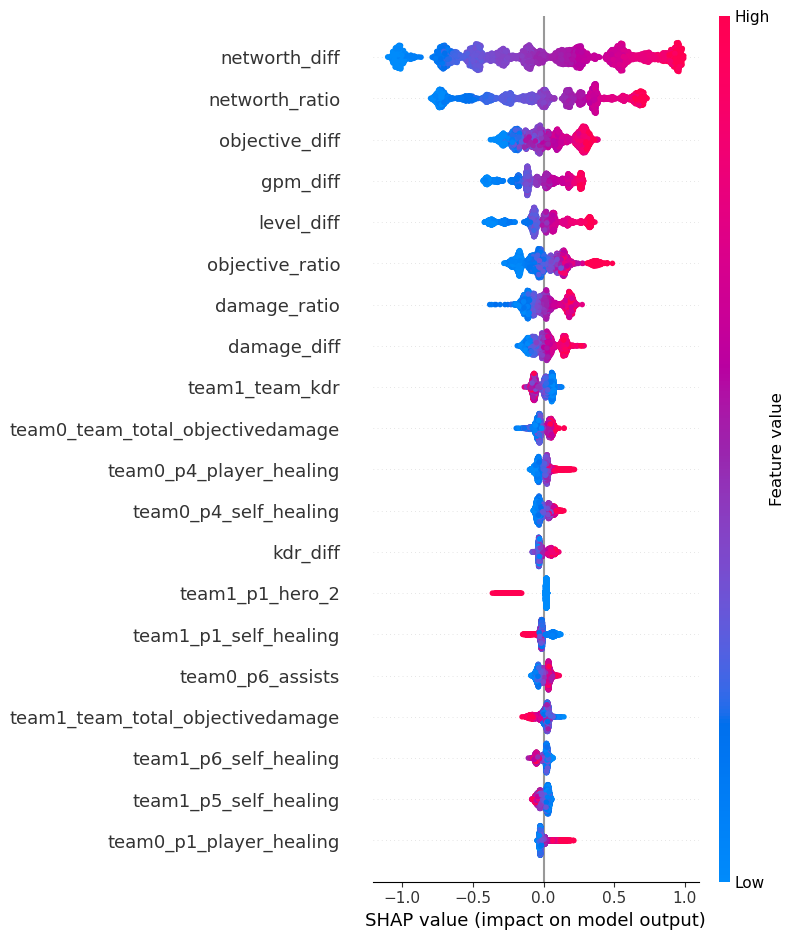

In [ ]:
import shap

explainer = shap.TreeExplainer(model_xgb)

shap_values = (explainer.shap_values(X_test))

shap.summary_plot(shap_values,X_test)

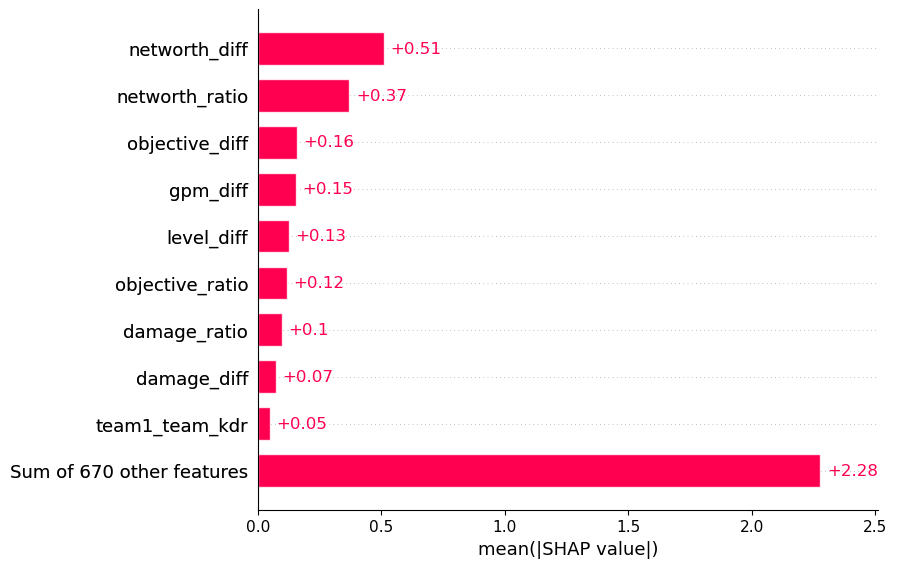

In [ ]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X_test.values, feature_names=X_test.columns))